In [28]:
import numpy as np
from scipy.stats import multivariate_normal
from sklearn.decomposition import PCA

from AutoencoderAPI.utils.files import load_mean_std
from AutoencoderAPI.utils.decibels import decibel_table_npy
from AutoencoderAPI.utils.correlation import second_order


In [29]:
signal_size = 30_000
path_train = 'Datasets/SNSPD/Paderborn/data/'
path_model = 'grid-search-SNSPD param 4/run 09/fold 0'
mean_model, std_model = load_mean_std(path_model)

#X_train = np.concatenate([np.load(f"{path_train}{fileName}").reshape(-1,signal_size)[::2, 3250:4500] for fileName in listdir(path_train)[::2]])
#X_train = (X_train - mean_model)/std_model
#X_zeros = X_train[np.min(X_train, axis=1) >= 1.6]
#X_train = X_train[np.min(X_train, axis=1) < -0.5]
#X_train = X_train[np.max(X_train, axis=1) > 1]

## Load

In [30]:
X, decibel_samples, decibel_zeros = decibel_table_npy('Datasets/SNSPD/Paderborn/data test', #, decibel_zeros
                                'Datasets/SNSPD/Paderborn/db_shuffled.npy', 
                                30_000,
                                mean_model, 
                                std_model)

condition = np.min(X, axis=1) < -1.5
X = X[condition]
decibel_samples = decibel_samples[condition]

# Poisson Gaussian Mixture

In [31]:
def init_params(X, K):
    """Initialize the parameters for the GMM.
    """
    n, d = X.shape
    np.random.seed(0)  # For reproducibility

    # Randomly initialize the means
    mu = X[np.random.choice(n, K, False), :]

    # Initialize the covariance matrices as identity matrices
    Sigma = [np.eye(d) for _ in range(K)]

    # Initialize the mixing coefficients uniformly
    pi = np.full(K, 1/K)

    return mu, Sigma, pi

In [32]:
def e_step(X, mu, Sigma, pi):
    """E-step: compute responsibilities.
    """
    N, K = X.shape[0], len(pi)
    responsibilities = np.zeros((N, K))

    for k in range(K):
        responsibilities[:, k] = pi[k] * multivariate_normal.pdf(X, mean=mu[k], cov=Sigma[k])

    # Normalize across components to get the probabilities
    responsibilities /= responsibilities.sum(axis=1, keepdims=True)

    return responsibilities

In [33]:
def m_step(X, responsibilities):
    """M-step: update parameters.
    """
    N, d = X.shape
    K = responsibilities.shape[1]

    # Number of data points assigned to each component
    Nk = responsibilities.sum(axis=0)

    # Update means
    mu = np.dot(responsibilities.T, X) / Nk[:, np.newaxis]

    # Update covariances
    Sigma = []
    for k in range(K):
        diff = X - mu[k]
        Sigma_k = np.dot(responsibilities[:, k] * diff.T, diff) / Nk[k]
        Sigma.append(Sigma_k)

    # Update mixing coefficients
    pi = Nk / N

    return mu, Sigma, pi

In [34]:
def gmm_em(X, K, max_iter=100):
    """Gaussian Mixture Model Estimation using Expectation-Maximization.
    """
    # Initialize parameters
    mu, Sigma, pi = init_params(X, K)

    for iteration in range(max_iter):
        # E-step
        responsibilities = e_step(X, mu, Sigma, pi)

        # M-step
        mu, Sigma, pi = m_step(X, responsibilities)

    return mu, Sigma, pi

## Confidence

In [35]:
decibel = []
g2 = []
average = []

method = PCA(n_components=1)
X_l = method.fit_transform(X)
X_l = (X_l-np.min(X_l)) / (np.max(X_l)-np.min(X_l))

for index, key in enumerate(np.unique(decibel_samples)):

    print(key)
    condition = decibel_samples == key
    zeros_number = len(decibel_zeros[decibel_zeros == key])

    X_ = X_l[condition]


mu, Sigma, pi = gmm_em(X_, 4, 200)

9.05
9.5
10.01
10.59
11.25
12.04
13.0
14.24
15.99
18.97


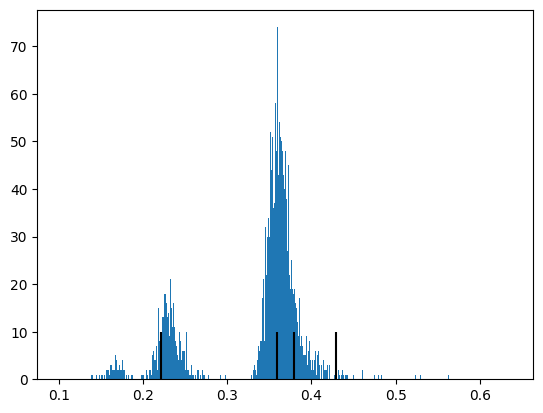

In [36]:
import matplotlib.pyplot as plt

plt.hist(X_, bins=5000)
plt.vlines(mu,0,10, colors='k')